In [14]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [15]:
image_path = "../output_videos/player_16.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

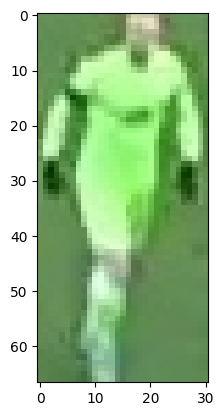

In [16]:
plt.imshow(image)
plt.show()

# take the top half of the image

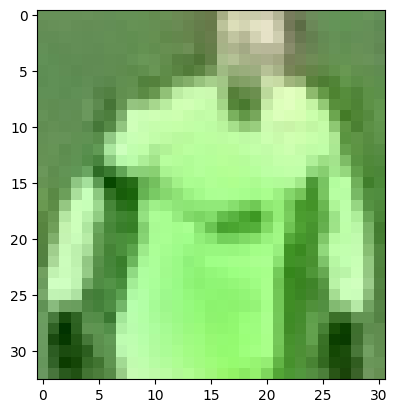

In [17]:
top_half_image = image[:(int(image.shape[0]//2)), :, :]
plt.imshow(top_half_image)
plt.show()

# Cluster the image into two clusters


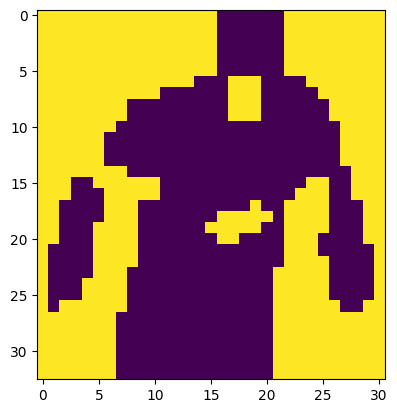

In [18]:
# reshape the image to a 2D array 

image_2d = top_half_image.reshape(-1, 3)

# perform k-means clustering to find the dominant colors
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

# get the cluster labels
labels = kmeans.labels_

# reshape the labels to match the original image shape
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

#display the clustered image
plt.imshow(clustered_image)
plt.show()

In [19]:
corner_cluster = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_cluster = max(set(corner_cluster), key=corner_cluster.count)
print(f"Non player cluster: {non_player_cluster}")

Non player cluster: 1


In [20]:
player_cluster = 1 - non_player_cluster
print(f"Player cluster: {player_cluster}")

Player cluster: 0


In [21]:
kmeans.cluster_centers_[player_cluster]

array([172.06313646, 238.77596741, 147.07942974])